# Bayesian Multilevel Hierarchical Model 

In [1]:
import pandas as pd
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# ensure jupyter environment is run in the 'dissertation' environment to ensure pymc model runs quickly

## Qualifying Model

### 2018 Qualifying Model

In [2]:
df_2018_quali = pd.read_csv('2018_season_quali_dataset.csv')

In [3]:
y = df_2018_quali['Normalised_Pole_Gap'].to_numpy(dtype = 'float64')

drivers = pd.Index(sorted(df_2018_quali['Driver'].unique()), name = 'driver')
constructors = pd.Index(sorted(df_2018_quali['Team'].unique()), name = 'constructor')
rounds = pd.Index(sorted(df_2018_quali['Season_Round'].unique()), name = 'round')

driver_no_id = df_2018_quali['Driver'].map({d:i for i, d in enumerate(drivers)}).to_numpy()
constructor_no_id = df_2018_quali['Team'].map({c:i for i, c in enumerate(constructors)}).to_numpy()
round_no_id = df_2018_quali['Season_Round'].map({r:i for i, r in enumerate(rounds)}).to_numpy()

n_drivers = len(drivers)
n_constructors = len(constructors)
n_rounds = len(rounds)

In [4]:
with pm.Model() as model:
    driver = pm.HalfNormal('driver', 0.01)
    constructor = pm.HalfNormal('constructor', 0.02)
    round = pm.HalfNormal('round', 0.005)
    # how much the variataion is from the 'average' - priors based on prior academic lit results
    
    raw_driver = pm.Normal('raw_driver', 0, 1, shape = n_drivers)
    raw_constructor = pm.Normal('raw_constructor', 0, 1, shape = n_constructors)
    raw_round = pm.Normal('raw_round', 0, 1, shape = n_rounds)

    driver_effect = pm.Deterministic('driver_effect', raw_driver * driver)
    constructor_effect = pm.Deterministic('constructor_effect', raw_constructor * constructor)
    round_effect = pm.Deterministic('round_effect', raw_round * round)

    sigma = pm.HalfNormal('sigma', 0.01)

    mean_pole_gap = driver_effect[driver_no_id] + constructor_effect[constructor_no_id] + round_effect[round_no_id]

    y_observations = pm.Normal('y_observations', mu = mean_pole_gap, sigma = sigma, observed = y)

    results_2018 = pm.sample(1000, tune = 1000, chains = 4, target_accept = 0.9, random_seed = 24)
    results_2018 = pm.sample_posterior_predictive(results_2018, var_names=['y_observations'], extend_inferencedata=True, random_seed=24)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [driver, constructor, round, raw_driver, raw_constructor, raw_round, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 36 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_observations]


Output()

In [ ]:
az.summary(results_2018, var_names = ['driver','constructor','round','sigma'], round_to=5)

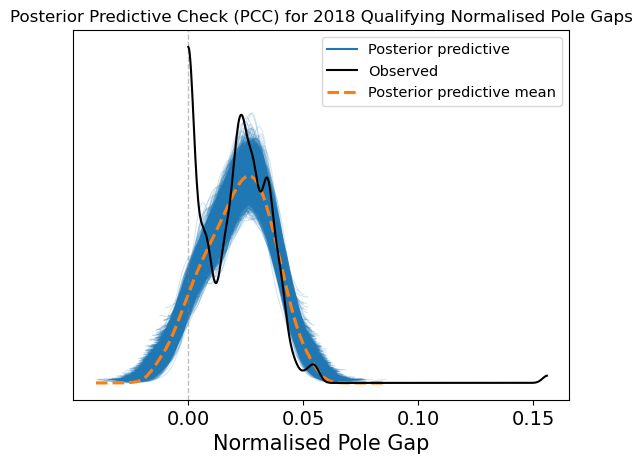

In [39]:
az.plot_ppc(results_2018)

plt.axvline(0, color='grey', lw=1, ls ='--', alpha=0.5)

plt.title('Posterior Predictive Check (PCC) for 2018 Qualifying Normalised Pole Gaps')
plt.xlabel('Normalised Pole Gap')
#plt.show()

plt.savefig('PCC_2018.png')

In [ ]:
constructor_2018_summary = (az.summary(results_2018, var_names = ['constructor_effect']).set_index(constructors).sort_values('mean'))
constructor_2018_summary['consistency'] = (constructor_2018_summary['hdi_97%'] - constructor_2018_summary['hdi_3%'])
print(constructor_2018_summary)

In [ ]:
driver_2018_summary = (az.summary(results_2018, var_names = ['driver_effect']).set_index(drivers).sort_values('mean'))
driver_2018_summary['consistency'] = (driver_2018_summary['hdi_97%'] - driver_2018_summary['hdi_3%'])
print(driver_2018_summary)

In [ ]:
round_2018_summary = (az.summary(results_2018, var_names = ['round_effect']).set_index(rounds).sort_values('mean'))
round_2018_summary['consistency'] = (round_2018_summary['hdi_97%'] - round_2018_summary['hdi_3%'])
print(round_2018_summary)

### 2025 Qualifying Model

In [24]:
df_2025_quali = pd.read_csv('2025_season_quali_dataset.csv')

In [25]:
y = df_2025_quali['Normalised_Pole_Gap'].to_numpy(dtype = 'float64')

drivers = pd.Index(sorted(df_2025_quali['Driver'].unique()), name = 'driver')
constructors = pd.Index(sorted(df_2025_quali['Team'].unique()), name = 'constructor')
rounds = pd.Index(sorted(df_2025_quali['Season_Round'].unique()), name = 'round')

driver_no_id = df_2025_quali['Driver'].map({d:i for i, d in enumerate(drivers)}).to_numpy()
constructor_no_id = df_2025_quali['Team'].map({c:i for i, c in enumerate(constructors)}).to_numpy()
round_no_id = df_2025_quali['Season_Round'].map({r:i for i, r in enumerate(rounds)}).to_numpy()

n_drivers = len(drivers)
n_constructors = len(constructors)
n_rounds = len(rounds)

In [35]:
with pm.Model() as model:
    driver = pm.HalfNormal('driver', 0.01)
    constructor = pm.HalfNormal('constructor', 0.02)
    round = pm.HalfNormal('round', 0.005)
    # how much the variataion is from the 'average' - priors based on prior academic lit results
    
    raw_driver = pm.Normal('raw_driver', 0, 1, shape = n_drivers)
    raw_constructor = pm.Normal('raw_constructor', 0, 1, shape = n_constructors)
    raw_round = pm.Normal('raw_round', 0, 1, shape = n_rounds)

    driver_effect = pm.Deterministic('driver_effect', raw_driver * driver)
    constructor_effect = pm.Deterministic('constructor_effect', raw_constructor * constructor)
    round_effect = pm.Deterministic('round_effect', raw_round * round)

    sigma = pm.HalfNormal('sigma', 0.01)

    mean_pole_gap = driver_effect[driver_no_id] + constructor_effect[constructor_no_id] + round_effect[round_no_id]

    y_observations = pm.Normal('y_observations', mu = mean_pole_gap, sigma = sigma, observed = y)

    results_2025 = pm.sample(1000, tune = 1000, chains = 4, target_accept = 0.9, random_seed = 24)
    results_2025 = pm.sample_posterior_predictive(results_2025, var_names=['y_observations'], extend_inferencedata=True, random_seed=24)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [driver, constructor, round, raw_driver, raw_constructor, raw_round, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.
Sampling: [y_observations]


Output()

In [ ]:
az.summary(results_2025, var_names = ['driver','constructor','round','sigma'], round_to=5)

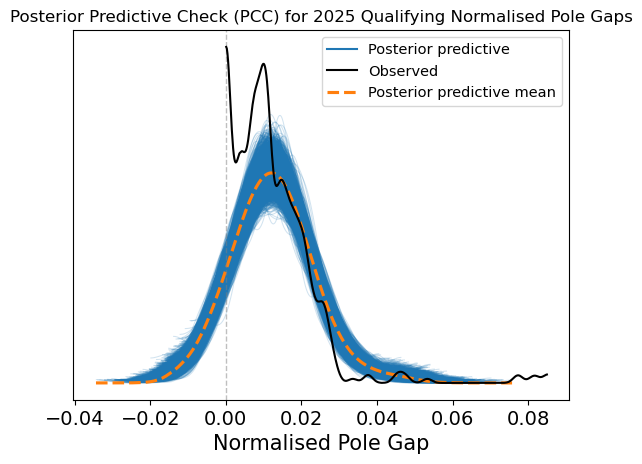

In [40]:
az.plot_ppc(results_2025)

plt.axvline(0, color='grey', lw=1, ls ='--', alpha=0.5)

plt.title('Posterior Predictive Check (PCC) for 2025 Qualifying Normalised Pole Gaps')
plt.xlabel('Normalised Pole Gap')
#plt.show()

plt.savefig('PCC_2025.png')

In [ ]:
constructor_2025_summary = (az.summary(results_2025, var_names = ['constructor_effect']).set_index(constructors).sort_values('mean'))
constructor_2025_summary['consistency'] = (constructor_2025_summary['hdi_97%'] - constructor_2025_summary['hdi_3%'])
print(constructor_2025_summary)

In [ ]:
driver_2025_summary = (az.summary(results_2025, var_names = ['driver_effect']).set_index(drivers).sort_values('mean'))
driver_2025_summary['consistency'] = (driver_2025_summary['hdi_97%'] - driver_2025_summary['hdi_3%'])
print(driver_2025_summary)

In [ ]:
round_2025_summary = (az.summary(results_2025, var_names = ['round_effect']).set_index(rounds).sort_values('mean'))
round_2025_summary['consistency'] = (round_2025_summary['hdi_97%'] - round_2025_summary['hdi_3%'])
print(round_2025_summary)

### All Seasons (2018-2025)

In [ ]:
df_all_season_quali = pd.read_csv('all_season_quali_dataset.csv')

In [ ]:
y = df_all_season_quali['Normalised_Pole_Gap'].to_numpy(dtype = 'float64')

drivers = pd.Index(sorted(df_all_season_quali['Driver'].unique()), name = 'driver')
constructors = pd.Index(sorted(df_all_season_quali['Team'].unique()), name = 'constructor')
rounds = pd.Index(sorted(df_all_season_quali['Season_Round'].unique()), name = 'round')

driver_no_id = df_all_season_quali['Driver'].map({d:i for i, d in enumerate(drivers)}).to_numpy()
constructor_no_id = df_all_season_quali['Team'].map({c:i for i, c in enumerate(constructors)}).to_numpy()
round_no_id = df_all_season_quali['Season_Round'].map({r:i for i, r in enumerate(rounds)}).to_numpy()

n_drivers = len(drivers)
n_constructors = len(constructors)
n_rounds = len(rounds)

In [ ]:
with pm.Model() as model:
    driver = pm.HalfNormal('driver', 0.01)
    constructor = pm.HalfNormal('constructor', 0.02)
    round = pm.HalfNormal('round', 0.005)
    # how much the variataion is from the 'average' - priors based on prior academic lit results
    
    raw_driver = pm.Normal('raw_driver', 0, 1, shape = n_drivers)
    raw_constructor = pm.Normal('raw_constructor', 0, 1, shape = n_constructors)
    raw_round = pm.Normal('raw_round', 0, 1, shape = n_rounds)

    driver_effect = pm.Deterministic('driver_effect', raw_driver * driver)
    constructor_effect = pm.Deterministic('constructor_effect', raw_constructor * constructor)
    round_effect = pm.Deterministic('round_effect', raw_round * round)

    sigma = pm.HalfNormal('sigma', 0.01)

    mean_pole_gap = driver_effect[driver_no_id] + constructor_effect[constructor_no_id] + round_effect[round_no_id]

    y_observations = pm.Normal('y_observations', mu = mean_pole_gap, sigma = sigma, observed = y)

    results_all_seasons = pm.sample(1000, tune = 1000, chains = 4, target_accept = 0.9, random_seed = 24)

In [ ]:
az.summary(results_all_seasons, var_names = ['driver','constructor','round','sigma'], round_to=5)

In [ ]:
constructor_all_seasons_summary = (az.summary(results_all_seasons, var_names = ['constructor_effect']).set_index(constructors).sort_values('mean'))
constructor_all_seasons_summary['consistency'] = (constructor_all_seasons_summary['hdi_97%'] - constructor_all_seasons_summary['hdi_3%'])
print(constructor_all_seasons_summary)

In [ ]:
driver_all_seasons_summary = (az.summary(results_all_seasons, var_names = ['driver_effect']).set_index(drivers).sort_values('mean'))
driver_all_seasons_summary['consistency'] = (driver_all_seasons_summary['hdi_97%'] - driver_all_seasons_summary['hdi_3%'])
print(driver_all_seasons_summary)

In [ ]:
round_all_seasons_summary = (az.summary(results_all_seasons, var_names = ['round_effect']).set_index(rounds).sort_values('mean'))
round_all_seasons_summary['consistency'] = (round_all_seasons_summary['hdi_97%'] - round_all_seasons_summary['hdi_3%'])
print(round_all_seasons_summary)

## Race Model

### 2018 Race Model

In [ ]:
df_2018_race = pd.read_csv('2018_season_race_dataset.csv')

In [ ]:
y = df_2018_race['Normalised_Race_Pole_Gap'].to_numpy(dtype = 'float64')

drivers = pd.Index(sorted(df_2018_race['Driver'].unique()), name = 'driver')
constructors = pd.Index(sorted(df_2018_race['Team'].unique()), name = 'constructor')
rounds = pd.Index(sorted(df_2018_race['Season_Round'].unique()), name = 'round')

driver_no_id = df_2018_race['Driver'].map({d:i for i, d in enumerate(drivers)}).to_numpy()
constructor_no_id = df_2018_race['Team'].map({c:i for i, c in enumerate(constructors)}).to_numpy()
round_no_id = df_2018_race['Season_Round'].map({r:i for i, r in enumerate(rounds)}).to_numpy()

n_drivers = len(drivers)
n_constructors = len(constructors)
n_rounds = len(rounds)

In [ ]:
with pm.Model() as model:
    driver = pm.HalfNormal('driver', 0.01)
    constructor = pm.HalfNormal('constructor', 0.02)
    round = pm.HalfNormal('round', 0.005)
    # how much the variataion is from the 'average' - priors based on prior academic lit results
    
    raw_driver = pm.Normal('raw_driver', 0, 1, shape = n_drivers)
    raw_constructor = pm.Normal('raw_constructor', 0, 1, shape = n_constructors)
    raw_round = pm.Normal('raw_round', 0, 1, shape = n_rounds)

    driver_effect = pm.Deterministic('driver_effect', raw_driver * driver)
    constructor_effect = pm.Deterministic('constructor_effect', raw_constructor * constructor)
    round_effect = pm.Deterministic('round_effect', raw_round * round)

    sigma = pm.HalfNormal('sigma', 0.01)

    mean_pole_gap = driver_effect[driver_no_id] + constructor_effect[constructor_no_id] + round_effect[round_no_id]

    y_observations = pm.Normal('y_observations', mu = mean_pole_gap, sigma = sigma, observed = y)

    results_2018_race = pm.sample(1000, tune = 1000, chains = 4, target_accept = 0.9, random_seed = 24)

In [ ]:
az.summary(results_2018_race, var_names = ['driver','constructor','round','sigma'], round_to=5)

In [ ]:
constructor_2018_race_summary = (az.summary(results_2018_race, var_names = ['constructor_effect']).set_index(constructors).sort_values('mean'))
print(constructor_2018_race_summary)

In [ ]:
driver_2018_race_summary = (az.summary(results_2018_race, var_names = ['driver_effect']).set_index(drivers).sort_values('mean'))
print(driver_2018_race_summary)

In [ ]:
round_2018_race_summary = (az.summary(results_2018_race, var_names = ['round_effect']).set_index(rounds).sort_values('mean'))
print(round_2018_race_summary)

### 2025 Race Model

In [ ]:
df_2025_race = pd.read_csv('2025_season_race_dataset.csv')

In [ ]:
y = df_2025_race['Normalised_Race_Pole_Gap'].to_numpy(dtype = 'float64')

drivers = pd.Index(sorted(df_2025_race['Driver'].unique()), name = 'driver')
constructors = pd.Index(sorted(df_2025_race['Team'].unique()), name = 'constructor')
rounds = pd.Index(sorted(df_2025_race['Season_Round'].unique()), name = 'round')

driver_no_id = df_2025_race['Driver'].map({d:i for i, d in enumerate(drivers)}).to_numpy()
constructor_no_id = df_2025_race['Team'].map({c:i for i, c in enumerate(constructors)}).to_numpy()
round_no_id = df_2025_race['Season_Round'].map({r:i for i, r in enumerate(rounds)}).to_numpy()

n_drivers = len(drivers)
n_constructors = len(constructors)
n_rounds = len(rounds)

In [ ]:
with pm.Model() as model:
    driver = pm.HalfNormal('driver', 0.01)
    constructor = pm.HalfNormal('constructor', 0.02)
    round = pm.HalfNormal('round', 0.005)
    # how much the variataion is from the 'average' - priors based on prior academic lit results
    
    raw_driver = pm.Normal('raw_driver', 0, 1, shape = n_drivers)
    raw_constructor = pm.Normal('raw_constructor', 0, 1, shape = n_constructors)
    raw_round = pm.Normal('raw_round', 0, 1, shape = n_rounds)

    driver_effect = pm.Deterministic('driver_effect', raw_driver * driver)
    constructor_effect = pm.Deterministic('constructor_effect', raw_constructor * constructor)
    round_effect = pm.Deterministic('round_effect', raw_round * round)

    sigma = pm.HalfNormal('sigma', 0.01)

    mean_pole_gap = driver_effect[driver_no_id] + constructor_effect[constructor_no_id] + round_effect[round_no_id]

    y_observations = pm.Normal('y_observations', mu = mean_pole_gap, sigma = sigma, observed = y)

    results_2025_race = pm.sample(1000, tune = 1000, chains = 4, target_accept = 0.9, random_seed = 24)

In [ ]:
az.summary(results_2025_race, var_names = ['driver','constructor','round','sigma'], round_to=5)

In [ ]:
constructor_2025_race_summary = (az.summary(results_2025_race, var_names = ['constructor_effect']).set_index(constructors).sort_values('mean'))
print(constructor_2025_race_summary)

In [ ]:
driver_2025_race_summary = (az.summary(results_2025_race, var_names = ['driver_effect']).set_index(drivers).sort_values('mean'))
print(driver_2025_race_summary)

In [ ]:
round_2025_race_summary = (az.summary(results_2025_race, var_names = ['round_effect']).set_index(rounds).sort_values('mean'))
print(round_2025_race_summary)

### All Seasons (2018-2025)

In [ ]:
df_all_season_race = pd.read_csv('all_season_race_dataset.csv')

In [ ]:
y = df_all_season_race['Normalised_Race_Pole_Gap'].to_numpy(dtype = 'float64')

drivers = pd.Index(sorted(df_all_season_race['Driver'].unique()), name = 'driver')
constructors = pd.Index(sorted(df_all_season_race['Team'].unique()), name = 'constructor')
rounds = pd.Index(sorted(df_all_season_race['Season_Round'].unique()), name = 'round')

driver_no_id = df_all_season_race['Driver'].map({d:i for i, d in enumerate(drivers)}).to_numpy()
constructor_no_id = df_all_season_race['Team'].map({c:i for i, c in enumerate(constructors)}).to_numpy()
round_no_id = df_all_season_race['Season_Round'].map({r:i for i, r in enumerate(rounds)}).to_numpy()

n_drivers = len(drivers)
n_constructors = len(constructors)
n_rounds = len(rounds)

In [ ]:
with pm.Model() as model:
    driver = pm.HalfNormal('driver', 0.01)
    constructor = pm.HalfNormal('constructor', 0.02)
    round = pm.HalfNormal('round', 0.005)
    # how much the variataion is from the 'average' - priors based on prior academic lit results
    
    raw_driver = pm.Normal('raw_driver', 0, 1, shape = n_drivers)
    raw_constructor = pm.Normal('raw_constructor', 0, 1, shape = n_constructors)
    raw_round = pm.Normal('raw_round', 0, 1, shape = n_rounds)

    driver_effect = pm.Deterministic('driver_effect', raw_driver * driver)
    constructor_effect = pm.Deterministic('constructor_effect', raw_constructor * constructor)
    round_effect = pm.Deterministic('round_effect', raw_round * round)

    sigma = pm.HalfNormal('sigma', 0.01)

    mean_pole_gap = driver_effect[driver_no_id] + constructor_effect[constructor_no_id] + round_effect[round_no_id]

    y_observations = pm.Normal('y_observations', mu = mean_pole_gap, sigma = sigma, observed = y)

    results_all_seasons_race = pm.sample(1000, tune = 1000, chains = 4, target_accept = 0.9, random_seed = 24)

In [ ]:
az.summary(results_all_seasons_race, var_names = ['driver','constructor','round','sigma'], round_to=5)

In [ ]:
constructor_all_seasons_race_summary = (az.summary(results_all_seasons_race, var_names = ['constructor_effect']).set_index(constructors).sort_values('mean'))
print(constructor_all_seasons_race_summary)

In [ ]:
driver_all_seasons_race_summary = (az.summary(results_all_seasons_race, var_names = ['driver_effect']).set_index(drivers).sort_values('mean'))
print(driver_all_seasons_race_summary)

In [ ]:
round_all_seasons_race_summary = (az.summary(results_all_seasons_race, var_names = ['round_effect']).set_index(rounds).sort_values('mean'))
print(round_all_seasons_race_summary)